# **Complex Systems: Final Project**
### Chialvo map:

$$
x_{n+1} = f(x_n, y_n) = x_n^2 exp(y_n - x_n) + k \\
y_{n+1} = g(y_n, x_n) = ay_n - b x_n + c 
$$

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import scienceplots

# Define the style
plt.style.use(['science', 'notebook', 'no-latex']) # Use a specific style for figures

In [19]:
# Define the Chialvo map functions

def xnext(x, y, k):
    """
    Compute the next x value in the Chialvo map.
    """
    return x**2 * np.exp(y - x) + k

def ynext(y, x, a, b, c):   
    """
    Compute the next y value in the Chialvo map.
    """
    return a * y - b * x + c

In [61]:
# y array
y = np.linspace(-1, 5, 100)

# x array
x = np.linspace(-1, 13, 100)

# Define the parameters
a = 0.89
b = 0.6
c = 0.28
k = 0.0

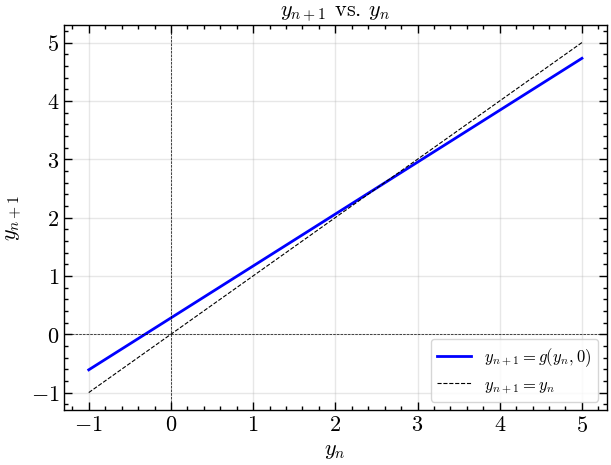

In [62]:
# Plot y_n vs. y_n+1
plt.figure(figsize=(7, 5))
plt.plot(y, ynext(y, 0, a, b, c), label=r'$y_{n+1} = g(y_n, 0)$', color='blue')
plt.plot(y, y, label=r'$y_{n+1} = y_n$', color='black', ls='--', lw=0.8)
plt.title(r'$y_{n+1}$ vs. $y_n$')
plt.xlabel(r'$y_n$')
plt.ylabel(r'$y_{n+1}$')
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.axvline(0, color='black', lw=0.5, ls='--')
plt.grid(alpha=0.3)
plt.legend(frameon=True, fontsize=12)
plt.show()

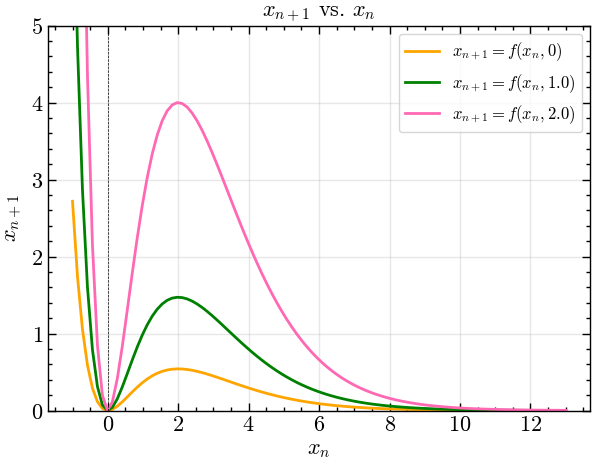

In [63]:
# Plot y_n vs. y_n+1
plt.figure(figsize=(7, 5))
plt.plot(x, xnext(x, 0, k), label=r'$x_{n+1} = f(x_n, 0)$', color='orange')
plt.plot(x, xnext(x, 1.0, k), label=r'$x_{n+1} = f(x_n, 1.0)$', color='green')
plt.plot(x, xnext(x, 2.0, k), label=r'$x_{n+1} = f(x_n, 2.0)$', color='hotpink')
plt.title(r'$x_{n+1}$ vs. $x_n$')
plt.xlabel(r'$x_n$')
plt.ylabel(r'$x_{n+1}$')
plt.ylim(0, 5)
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.axvline(0, color='black', lw=0.5, ls='--')
plt.grid(alpha=0.3)
plt.legend(frameon=True, fontsize=12)
plt.show()

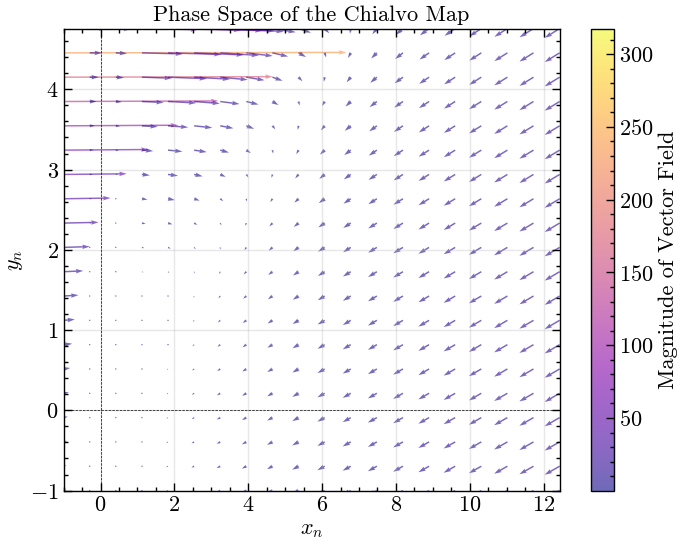

In [75]:
X, Y = np.meshgrid(x, y)
U = xnext(X, Y, k) - X
V = ynext(Y, X, a, b, c) - Y
# Compute module of vectors
magnitude = np.sqrt(U**2 + V**2)


# Interpolate for better visualization
fac_reduction = 5
new_x = x[::fac_reduction]
new_y = y[::fac_reduction]
grid_x, grid_y = np.meshgrid(new_x, new_y)
U_interp = griddata((X.flatten(), Y.flatten()), U.flatten(), (grid_x, grid_y), method='cubic')
V_interp = griddata((X.flatten(), Y.flatten()), V.flatten(), (grid_x, grid_y), method='cubic')
magnitude = np.sqrt(U_interp**2 + V_interp**2)

plt.figure(figsize=(8, 6))
plt.quiver(grid_x, grid_y, U_interp, V_interp, magnitude, cmap='plasma', alpha=0.6)
plt.title('Phase Space of the Chialvo Map')
plt.xlabel(r'$x_n$')
plt.ylabel(r'$y_n$')
plt.xlim(new_x.min(), new_x.max())
plt.ylim(new_y.min(), new_y.max())
plt.colorbar(label='Magnitude of Vector Field')
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.axvline(0, color='black', lw=0.5, ls='--')
plt.grid(alpha=0.3)
plt.show()

In [3]:
class ChialvoMap:
    def __init__(self, a=0.89, b=0.6, c=0.28, k=0.025, T=1000):
        self.a = a
        self.b = b
        self.c = c
        self.k = k
        self.T = T
        self.trajectory = np.zeros((self.T, 2))

    def step(self):
        x_new = self.x**2 * np.exp(self.y - self.x) + self.k
        y_new = self.a * self.y - self.b * self.x + self.c
        self.x, self.y = x_new, y_new

        return [self.x, self.y]

    def run(self, x0=0.0, y0=0.0):     
        self.x, self.y = x0, y0

        for t in range(self.T):
            self.trajectory[t] = self.step()

        return np.array(self.trajectory)

    def plot_trajectory(self):
        plt.plot(self.trajectory[:, 0], self.trajectory[:, 1])
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Chialvo Map Trajectory')
        plt.show()

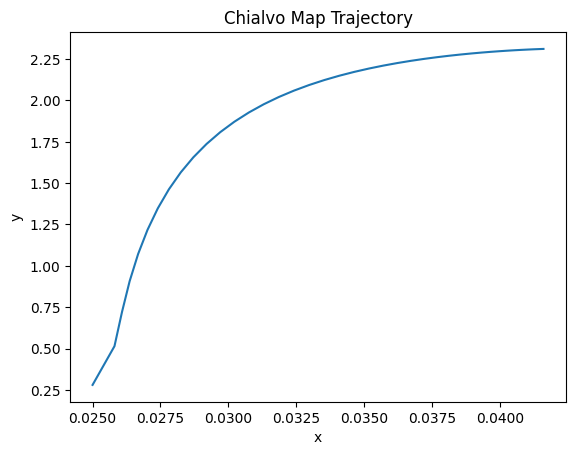

In [10]:
chialvo = ChialvoMap(T=40)
trajectory = chialvo.run(x0=0.0, y0=0.0)
chialvo.plot_trajectory()

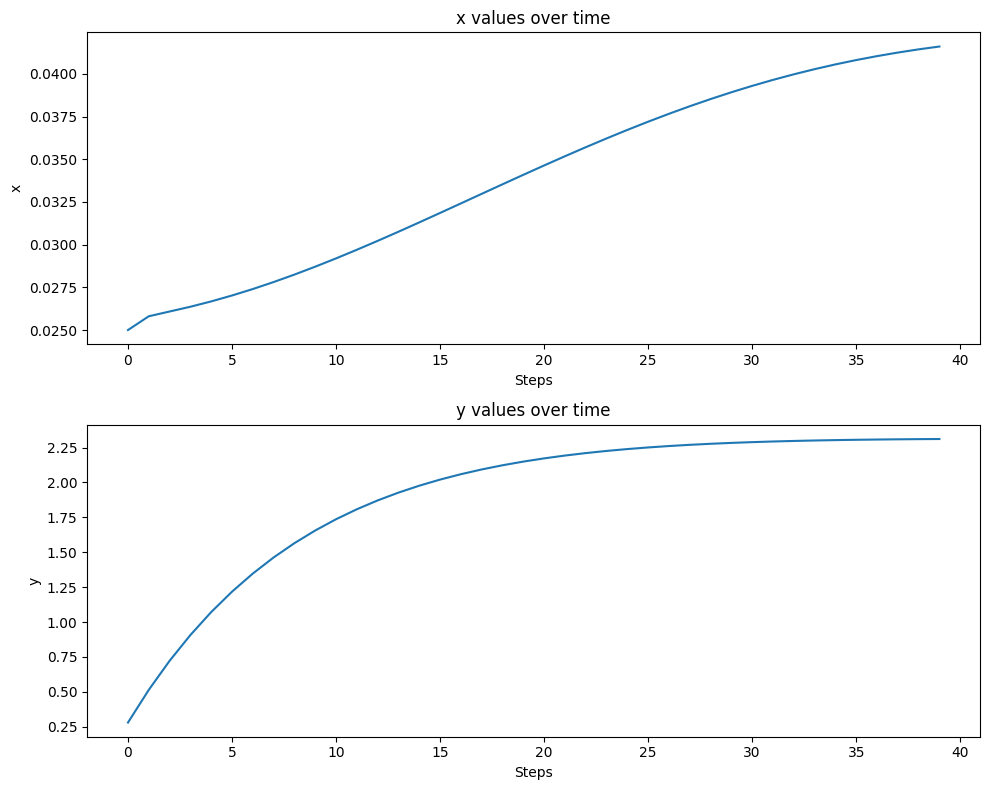

In [11]:
# plot steps vs. x and y values
fig = plt.subplots(2, 1, figsize=(10, 8))
plt.subplot(2, 1, 1)
plt.plot(trajectory[:, 0])
plt.title('x values over time')
plt.xlabel('Steps')
plt.ylabel('x')
plt.subplot(2, 1, 2)
plt.plot(trajectory[:, 1])
plt.title('y values over time')
plt.xlabel('Steps')
plt.ylabel('y')
plt.tight_layout()
plt.show()